# Phase 2

## فاز اول: بررسی و پروفایل کردن دیتا

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from skimage.feature import hog
from skimage import exposure
from sklearn.decomposition import PCA
from skimage.feature import local_binary_pattern
from skimage.feature import hog, graycomatrix, graycoprops
from skimage.color import rgb2gray
from skimage.measure import moments_hu
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import random
from skimage.feature import hog, graycomatrix, graycoprops
from skimage.measure import moments_hu
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import seaborn as sns

In [2]:
dataset_path = 'Animals-10'

In [3]:
classes = sorted(os.listdir(dataset_path))
print(classes)

['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


count in class
butterfly: 2112
cat: 1668
chicken: 3098
cow: 1866
dog: 4863
elephant: 1446
horse: 2623
sheep: 1820
spider: 4821
squirrel: 1862


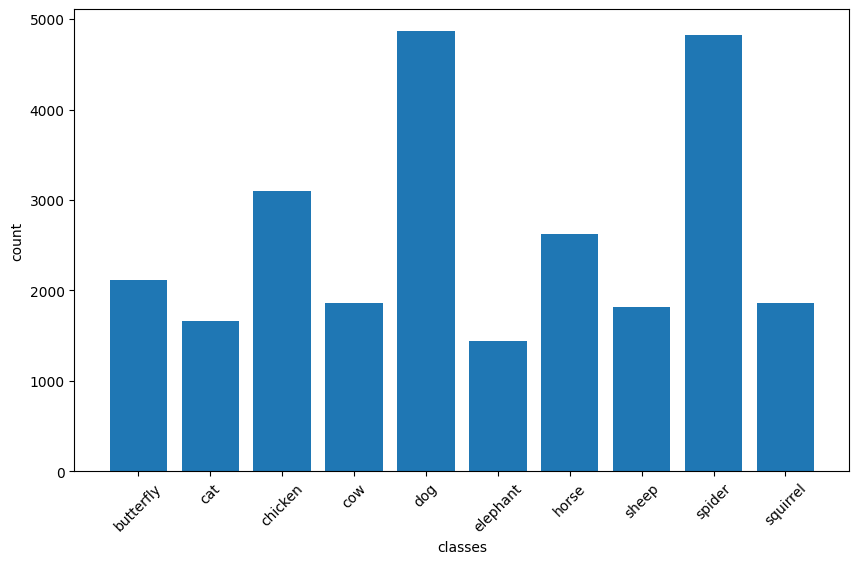

In [4]:
class_distribution = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_distribution[cls] = len(images)

print("count in class")
for cls, count in class_distribution.items():
    print(f"{cls}: {count}")

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('classes')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

In [5]:
sample_size = 1000
dimensions = [] 
color_modes = []

for cls in tqdm(classes):
    cls_path = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sampled_images = random.sample(images, min(sample_size, len(images)))
    
    for img_file in sampled_images:
        img_path = os.path.join(cls_path, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, c = img.shape
            dimensions.append((h, w))
            color_modes.append('grayscale' if c == 1 else 'color')

heights = [d[0] for d in dimensions]
widths = [d[1] for d in dimensions]

print(f"average heights: {np.mean(heights):.2f}")
print(f" average widths: {np.mean(widths):.2f}")
print(f" min heights: {min(heights)}, max heights: {max(heights)}")
print(f" min widths: {min(widths)}, max widths: {max(widths)}")

#need resize

100%|██████████| 10/10 [00:05<00:00,  1.70it/s]

average heights: 259.99
 average widths: 333.88
 min heights: 57, max heights: 6000
 min widths: 60, max widths: 6016


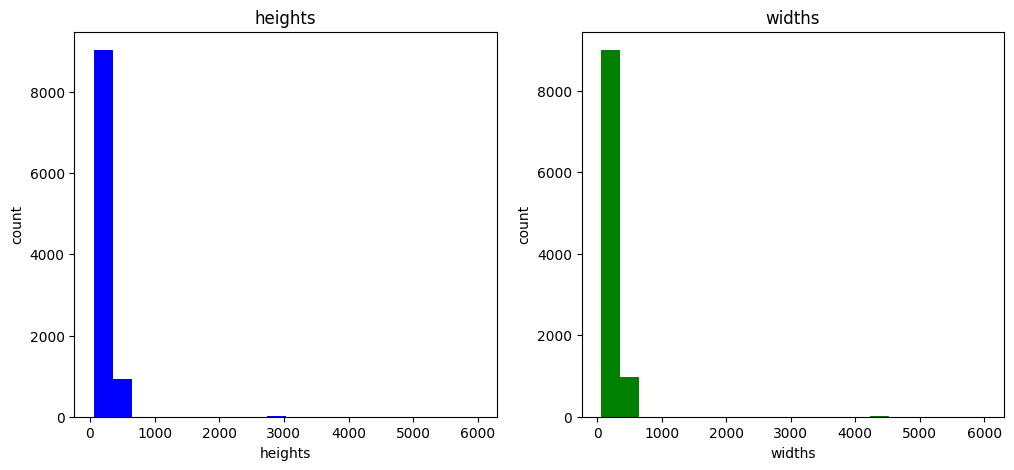

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(heights, bins=20, color='blue')
plt.title('heights')
plt.xlabel('heights')
plt.ylabel('count')

plt.subplot(1, 2, 2)
plt.hist(widths, bins=20, color='green')
plt.title('widths')
plt.xlabel('widths')
plt.ylabel('count')

plt.show()


 colors:
color: 10000  images


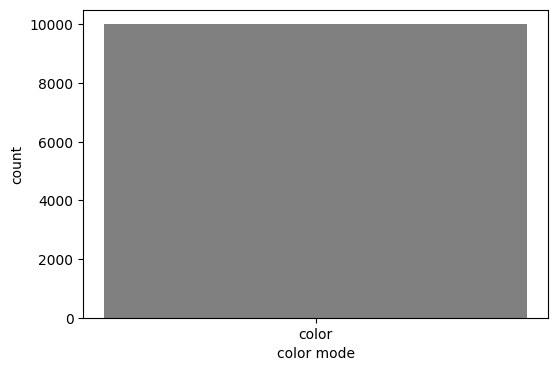

In [7]:
color_count = Counter(color_modes)

print("\n colors:")
for mode, count in color_count.items():
    print(f"{mode}: {count}  images")

plt.figure(figsize=(6, 4))
plt.bar(color_count.keys(), color_count.values(), color=['gray', 'blue'])
plt.xlabel('color mode')
plt.ylabel('count')
plt.show()

In [8]:
# mean for brightness(mean pixel value) and std for contrast
brightness_per_class = {cls: [] for cls in classes}
contrast_per_class = {cls: [] for cls in classes}

for cls in tqdm(classes):
    cls_path = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sampled_images = random.sample(images, min(sample_size, len(images)))
    
    for img_file in sampled_images:
        img_path = os.path.join(cls_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)    
        if img is not None:
            brightness = np.mean(img)
            contrast = np.std(img)
            brightness_per_class[cls].append(brightness)
            contrast_per_class[cls].append(contrast)

avg_brightness = {cls: np.mean(vals) for cls, vals in brightness_per_class.items()}
avg_contrast = {cls: np.mean(vals) for cls, vals in contrast_per_class.items()}

print("\n average brightness per class:")
for cls, val in avg_brightness.items():
    print(f"{cls}: {val:.2f}")

print("\n average contrast per class:")
for cls, val in avg_contrast.items():
    print(f"{cls}: {val:.2f}")

100%|██████████| 10/10 [00:09<00:00,  1.08it/s]


 average brightness per class:
butterfly: 126.18
cat: 128.05
chicken: 123.05
cow: 121.49
dog: 128.79
elephant: 124.57
horse: 125.04
sheep: 120.39
spider: 135.07
squirrel: 117.60

 average contrast per class:
butterfly: 56.64
cat: 57.85
chicken: 56.82
cow: 58.41
dog: 57.51
elephant: 56.53
horse: 59.77
sheep: 53.35
spider: 46.38
squirrel: 52.09


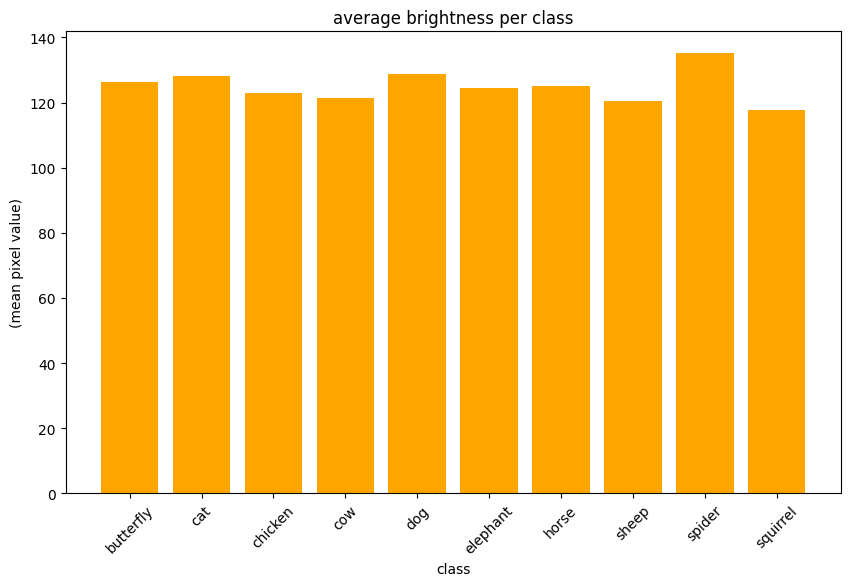

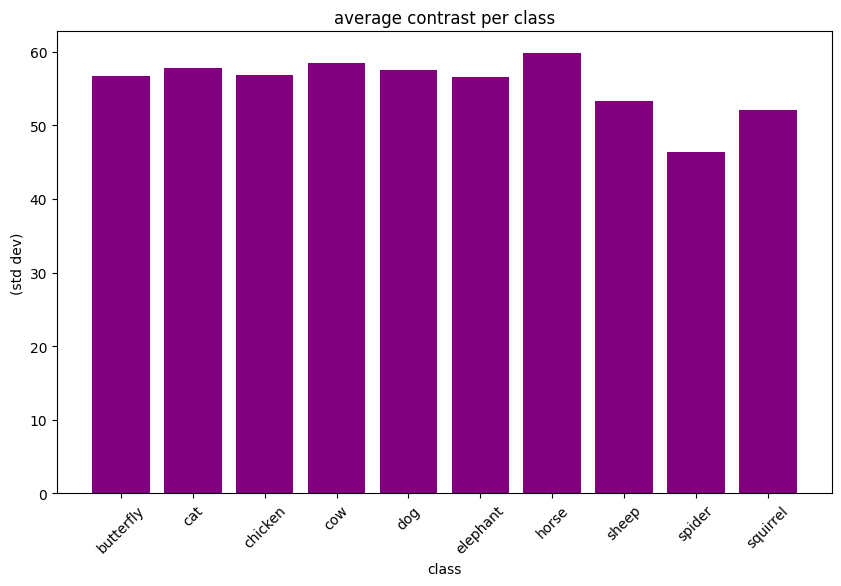

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(avg_brightness.keys(), avg_brightness.values(), color='orange')
plt.title('average brightness per class')
plt.xlabel('class')
plt.ylabel('(mean pixel value)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(avg_contrast.keys(), avg_contrast.values(), color='purple')
plt.title('average contrast per class')
plt.xlabel('class')
plt.ylabel('(std dev)')
plt.xticks(rotation=45)
plt.show()

In [10]:
color_dist_per_class = {cls: {'R': [], 'G': [], 'B': []} for cls in classes}

for cls in tqdm(classes):
    cls_path = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sampled_images = random.sample(images, min(sample_size, len(images)))
    
    for img_file in sampled_images:
        img_path = os.path.join(cls_path, img_file)
        img = cv2.imread(img_path)
        if img is not None and len(img.shape) == 3:
            mean_b, mean_g, mean_r = np.mean(img, axis=(0,1))
            color_dist_per_class[cls]['R'].append(mean_r)
            color_dist_per_class[cls]['G'].append(mean_g)
            color_dist_per_class[cls]['B'].append(mean_b)

# average RGB per class
avg_colors = {}
for cls in classes:
    avg_r = np.mean(color_dist_per_class[cls]['R'])
    avg_g = np.mean(color_dist_per_class[cls]['G'])
    avg_b = np.mean(color_dist_per_class[cls]['B'])
    avg_colors[cls] = (avg_r, avg_g, avg_b)
    print(f"{cls}: avg RGB = ({avg_r:.2f}, {avg_g:.2f}, {avg_b:.2f})")

100%|██████████| 10/10 [00:18<00:00,  1.89s/it]

butterfly: avg RGB = (128.73, 128.16, 97.65)
cat: avg RGB = (135.65, 127.42, 114.73)
chicken: avg RGB = (127.08, 122.11, 101.67)
cow: avg RGB = (124.24, 124.18, 100.61)
dog: avg RGB = (136.75, 130.49, 111.53)
elephant: avg RGB = (130.86, 125.06, 106.90)
horse: avg RGB = (128.37, 125.78, 104.80)
sheep: avg RGB = (125.85, 126.15, 98.21)
spider: avg RGB = (142.13, 135.74, 110.17)
squirrel: avg RGB = (123.68, 118.89, 95.78)


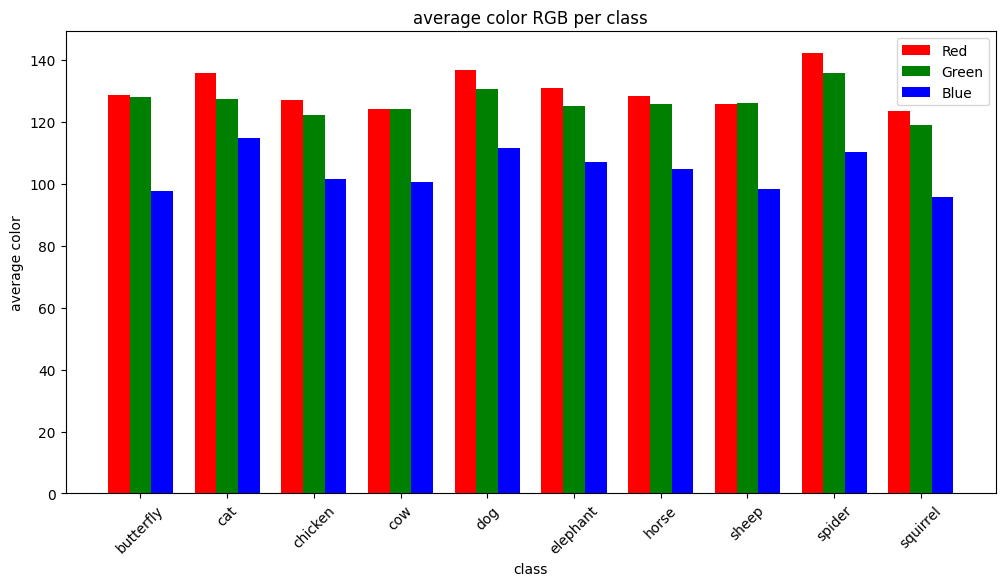

In [11]:
labels = list(avg_colors.keys())
r_means = [avg_colors[cls][0] for cls in labels]
g_means = [avg_colors[cls][1] for cls in labels]
b_means = [avg_colors[cls][2] for cls in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, r_means, width, label='Red', color='red')
ax.bar(x, g_means, width, label='Green', color='green')
ax.bar(x + width, b_means, width, label='Blue', color='blue')

ax.set_xlabel('class')
ax.set_ylabel('average color')
ax.set_title('average color RGB per class')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

plt.show()

---
## فاز دوم: استخراج ویژگی

In [12]:
IMG_SIZE = (128, 128)

In [13]:
def load_and_resize_images(sample_size=1000):# sampling
    images = []
    labels = []
    for cls_idx, cls in enumerate(classes):
        cls_path = os.path.join(dataset_path, cls)
        img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sampled_files = random.sample(img_files, min(sample_size, len(img_files)))
        for img_file in tqdm(sampled_files, desc=f"{cls}"):
            img_path = os.path.join(cls_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:

                resized_img = cv2.resize(img, IMG_SIZE)
                images.append(resized_img)
                labels.append(cls_idx)
    return np.array(images), np.array(labels)

images, labels = load_and_resize_images(sample_size=1000)
print(f"loaded images : {len(images)}")

squirrel: 100%|██████████| 1000/1000 [00:00<00:00, 2203.70it/s]


loaded images : 10000


In [14]:
def extract_hog_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    features, _ = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    return features

In [15]:
def extract_color_histogram(image):
    hist_r = cv2.calcHist([image], [0], None, [32], [0, 256])
    hist_g = cv2.calcHist([image], [1], None, [32], [0, 256])
    hist_b = cv2.calcHist([image], [2], None, [32], [0, 256])
    features = np.concatenate([hist_r, hist_g, hist_b]).flatten()
    return features

In [16]:
def extract_texture_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    features = np.array([contrast, dissimilarity, homogeneity, energy, correlation])
    return features

In [17]:
def extract_hu_moments(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    moments = cv2.moments(gray)
    hu_moments = cv2.HuMoments(moments).flatten()
    return hu_moments

In [18]:
def extract_edge_density(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    density = np.sum(edges > 0) / (edges.shape[0] * edges.shape[1])

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_contours = len(contours)
    features = np.array([density, num_contours])
    return features

In [19]:
def extract_color_moments(image):
    features = []
    for channel in cv2.split(image):
        mean = np.mean(channel)
        std = np.std(channel)
        skewness = np.mean(((channel - mean) / std) ** 3) if std != 0 else 0
        features.extend([mean, std, skewness])
    return np.array(features)



In [20]:
def extract_hsv_averages(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    features = []
    for channel in cv2.split(hsv):
        mean = np.mean(channel)
        std = np.std(channel)
        features.extend([mean, std])
    return np.array(features)



In [21]:
def extract_all_features(image):
    hog_f = extract_hog_features(image)
    color_hist = extract_color_histogram(image)
    texture = extract_texture_features(image)
    hu = extract_hu_moments(image)
    edge = extract_edge_density(image)
    color_mom = extract_color_moments(image)
    hsv = extract_hsv_averages(image)

    all_features = np.concatenate([hog_f, color_hist, texture, hu, edge, color_mom, hsv])
    return all_features

#sample
sample_img = images[0]
features = extract_all_features(sample_img)
print(f"features(dimentions): {features.shape}")

features(dimentions): (8225,)


The 8225 features come from concatenating the outputs of all seven feature extraction methods we defined in phase 2 (before any normalization or PCA in phase 3). This creates a high-dimensional vector per image that's rich but complex for models like DT or SVM (as per your notes on feature spaces and separators). Here's the exact breakdown per method, based on a 128x128 resized image:

HOG (Histogram of Oriented Gradients): 8100 features. This is the largest part—HOG divides the image into a 16x16 grid of cells (128/8=16), with 15x15=225 overlapping blocks, and 36 values per block (9 orientations x 4 cells). It captures edge directions and shapes, which is why it's so detailed.
Color Histogram: 96 features. 32 bins per RGB channel x 3 channels = 96. This quantizes color distributions.
Texture (GLCM): 5 features. Scalar stats like contrast, dissimilarity, etc., from the co-occurrence matrix.
Hu Moments: 7 features. Invariant shape descriptors.
Edge Density: 2 features. Density ratio + contour count from Canny edges.
Color Moments: 9 features. Mean, std, skewness x 3 RGB channels.
HSV Averages: 6 features. Mean + std x 3 HSV channels.

Total: 8100 + 96 + 5 + 7 + 2 + 9 + 6 = 8225. We normalize afterward to center/scale the data (e.g., for SVM margins), but the raw count is from this combo to make features discriminative for animals.

---
## فاز سوم: آموزش مدل

In [22]:
def load_and_extract_features(sample_size=200):
    all_features = []
    labels = []
    for cls_idx, cls in enumerate(tqdm(classes, desc="classes")):
        cls_path = os.path.join(dataset_path, cls)
        img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sampled_files = random.sample(img_files, min(sample_size, len(img_files)))
        for img_file in tqdm(sampled_files, desc=f"extracted {cls}", leave=False):
            img_path = os.path.join(cls_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:

                resized_img = cv2.resize(img, IMG_SIZE)
                features = extract_all_features(resized_img)
                all_features.append(features)
                labels.append(cls_idx)

    return np.array(all_features), np.array(labels)

In [23]:
X, y = load_and_extract_features(sample_size=1000)
print(f" features: {X.shape}, labels: {y.shape}")

classes: 100%|██████████| 10/10 [03:57<00:00, 23.71s/it]


 features: (10000, 8225), labels: (10000,)


In [24]:
# normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)
print(f"after reducing dimention by PCA: {X_pca.shape}")


X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

after reducing dimention by PCA: (10000, 100)
Train: (8000, 100), Test: (2000, 100)


after extracting the 8225 raw features per image (from concatenating all the methods like HOG, histograms, etc.), we apply PCA to reduce the dimensionality to 100 principal components. This helps make the data more manageable for models like DT and SVM (e.g., avoiding overfitting in trees or computational issues in SVM margins, as per your notes on separators and tree costs), while retaining most of the variance/information.

In [25]:
dt_base = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_base.fit(X_train, y_train)


y_pred_base_dt = dt_base.predict(X_test)
acc_base_dt = accuracy_score(y_test, y_pred_base_dt)
print(f" accurecy DT: {acc_base_dt:.4f}")
print(classification_report(y_test, y_pred_base_dt, target_names=classes))

 accurecy DT: 0.2590
              precision    recall  f1-score   support

   butterfly       0.32      0.35      0.34       200
         cat       0.23      0.20      0.22       200
     chicken       0.30      0.29      0.29       200
         cow       0.27      0.28      0.27       200
         dog       0.17      0.17      0.17       200
    elephant       0.26      0.29      0.27       200
       horse       0.31      0.29      0.30       200
       sheep       0.26      0.26      0.26       200
      spider       0.31      0.32      0.31       200
    squirrel       0.15      0.14      0.14       200

    accuracy                           0.26      2000
   macro avg       0.26      0.26      0.26      2000
weighted avg       0.26      0.26      0.26      2000



In [26]:
param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(criterion='gini', random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

# choosen parameters
dt_tuned = grid_dt.best_estimator_
print(f"best parameters DT: {grid_dt.best_params_}")


y_pred_tuned_dt = dt_tuned.predict(X_test)
acc_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
print(f"acc for tuned DT: {acc_tuned_dt:.4f}")
print(classification_report(y_test, y_pred_tuned_dt, target_names=classes, zero_division=0))

best parameters DT: {'class_weight': None, 'max_depth': 5, 'min_samples_split': 2}
acc for tuned DT: 0.2685
              precision    recall  f1-score   support

   butterfly       0.34      0.41      0.37       200
         cat       0.20      0.14      0.16       200
     chicken       0.40      0.35      0.37       200
         cow       0.20      0.20      0.20       200
         dog       0.17      0.13      0.15       200
    elephant       0.44      0.07      0.12       200
       horse       0.24      0.34      0.28       200
       sheep       0.37      0.35      0.36       200
      spider       0.44      0.28      0.34       200
    squirrel       0.18      0.41      0.25       200

    accuracy                           0.27      2000
   macro avg       0.30      0.27      0.26      2000
weighted avg       0.30      0.27      0.26      2000



we provide a grid of options for key hyper-parameters like tree depth (max_depth for controlling complexity/overfitting), minimum samples per split (min_samples_split for better splits), and class weights (to handle imbalance). GridSearchCV then tests all combinations on the training data via 5-fold cross-validation (splitting train into subsets, training/validating repeatedly to score each combo reliably). It selects the best combo based on average accuracy, retrains the DT with those params on the full train set, and finally evaluates it on the unseen test data (predict + accuracy/report), just like the baseline but optimized. This improves performance as per your project phase 3, tying to DT notes on efficient, transparent learning.

In [27]:
svm_base = SVC(kernel='rbf', random_state=42)
svm_base.fit(X_train, y_train)

y_pred_base_svm = svm_base.predict(X_test)
acc_base_svm = accuracy_score(y_test, y_pred_base_svm)
print(f"acc for SVM: {acc_base_svm:.4f}")
print(classification_report(y_test, y_pred_base_svm, target_names=classes))

acc for SVM: 0.4740
              precision    recall  f1-score   support

   butterfly       0.52      0.62      0.56       200
         cat       0.41      0.42      0.41       200
     chicken       0.48      0.57      0.52       200
         cow       0.50      0.50      0.50       200
         dog       0.30      0.23      0.26       200
    elephant       0.59      0.54      0.56       200
       horse       0.56      0.52      0.54       200
       sheep       0.44      0.48      0.46       200
      spider       0.55      0.56      0.55       200
    squirrel       0.34      0.29      0.32       200

    accuracy                           0.47      2000
   macro avg       0.47      0.47      0.47      2000
weighted avg       0.47      0.47      0.47      2000



In [28]:
param_grid_svm = {
    'C': [0.1, 1, 10],# margin(soft to hard)
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf'], #focus on non-linear
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy') #5-fold CV on train data (robust scoring, avoids single-split bias)
grid_svm.fit(X_train, y_train)


svm_tuned = grid_svm.best_estimator_
print(f"best SVM: {grid_svm.best_params_}")


y_pred_tuned_svm = svm_tuned.predict(X_test)
acc_tuned_svm = accuracy_score(y_test, y_pred_tuned_svm)
print(f"acc for tuned SVM: {acc_tuned_svm:.4f}")
print(classification_report(y_test, y_pred_tuned_svm, target_names=classes))

best SVM: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
acc for tuned SVM: 0.4895
              precision    recall  f1-score   support

   butterfly       0.53      0.67      0.59       200
         cat       0.41      0.45      0.43       200
     chicken       0.51      0.57      0.54       200
         cow       0.49      0.52      0.51       200
         dog       0.36      0.31      0.33       200
    elephant       0.54      0.53      0.53       200
       horse       0.55      0.51      0.53       200
       sheep       0.49      0.46      0.47       200
      spider       0.59      0.59      0.59       200
    squirrel       0.39      0.29      0.33       200

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



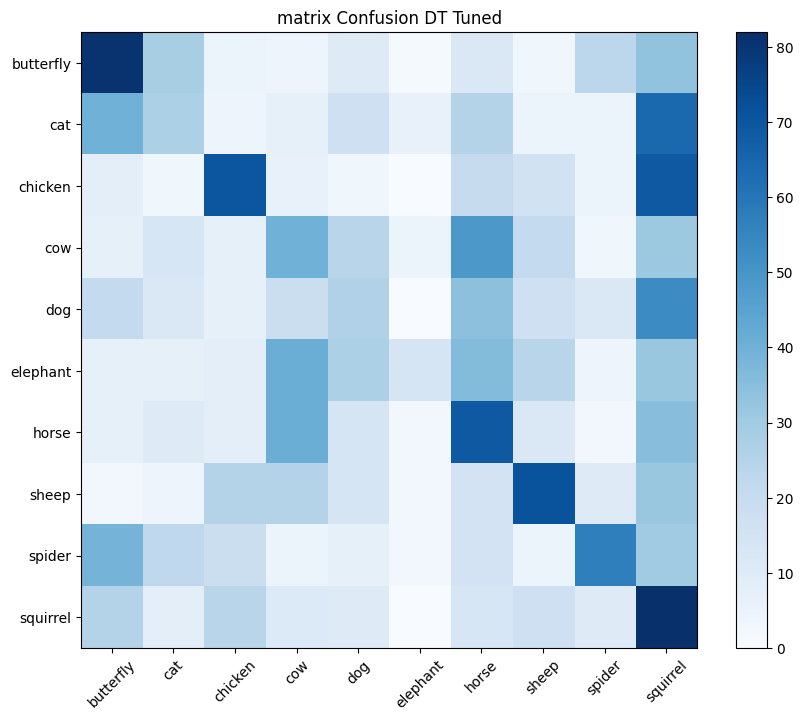

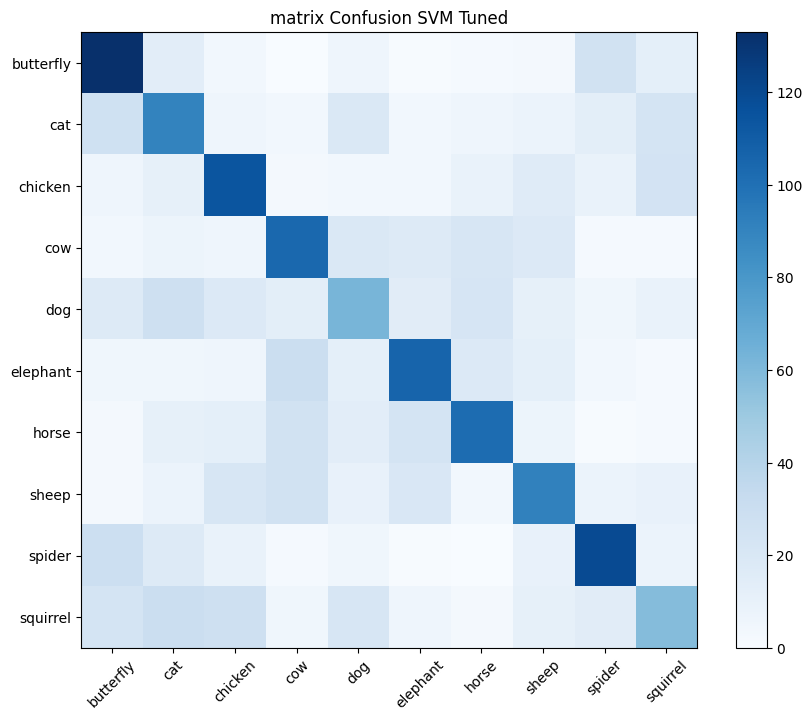

In [29]:
cm_dt = confusion_matrix(y_test, y_pred_tuned_dt)
plt.figure(figsize=(10, 8))
plt.imshow(cm_dt, cmap='Blues')
plt.title('matrix Confusion DT Tuned')
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
plt.show()

cm_svm = confusion_matrix(y_test, y_pred_tuned_svm)
plt.figure(figsize=(10, 8))
plt.imshow(cm_svm, cmap='Blues')
plt.title('matrix Confusion SVM Tuned')
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
plt.show()

---
## فاز چهارم: ارزیابی مدل

In [30]:
models = {
    'Base DT': y_pred_base_dt,
    'Tuned DT': y_pred_tuned_dt,
    'Base SVM': y_pred_base_svm,
    'Tuned SVM': y_pred_tuned_svm
}

In [34]:
metrics_df = pd.DataFrame(columns=['Model', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)'])

for model_name, y_pred in models.items():
    # Precision (macro): Avg true positives / (true + false positives) across classes (how accurate positive predictions are).
    prec = precision_score(y_test, y_pred, average='macro')

    # Recall (macro): Avg true positives / (true positives + false negatives) (how many actual positives caught).
    rec = recall_score(y_test, y_pred, average='macro')

    # F1-Score (macro): Harmonic mean of precision/recall (balances them, good for imbalance).
    f1 = f1_score(y_test, y_pred, average='macro')


    metrics_df = pd.concat([metrics_df, pd.DataFrame({
        'Model': [model_name],
        'Precision (macro)': [prec],
        'Recall (macro)': [rec],
        'F1-Score (macro)': [f1]
    })], ignore_index=True)

display(metrics_df)

C:\Users\sasan_wmsfg3b\AppData\Local\Temp\ipykernel_10720\2568024001.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, pd.DataFrame({


,Model,Precision (macro),Recall (macro),F1-Score (macro)
0,Base DT,0.257647,0.2590,0.257944
1,Tuned DT,0.297586,0.2685,0.261263
2,Base SVM,0.469455,0.4740,0.470044
3,Tuned SVM,0.485039,0.4895,0.485218


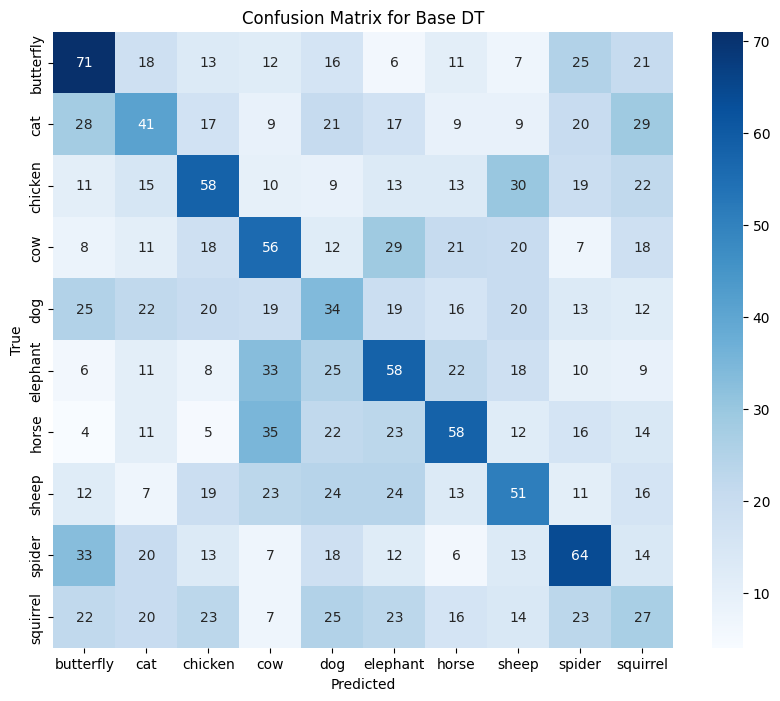

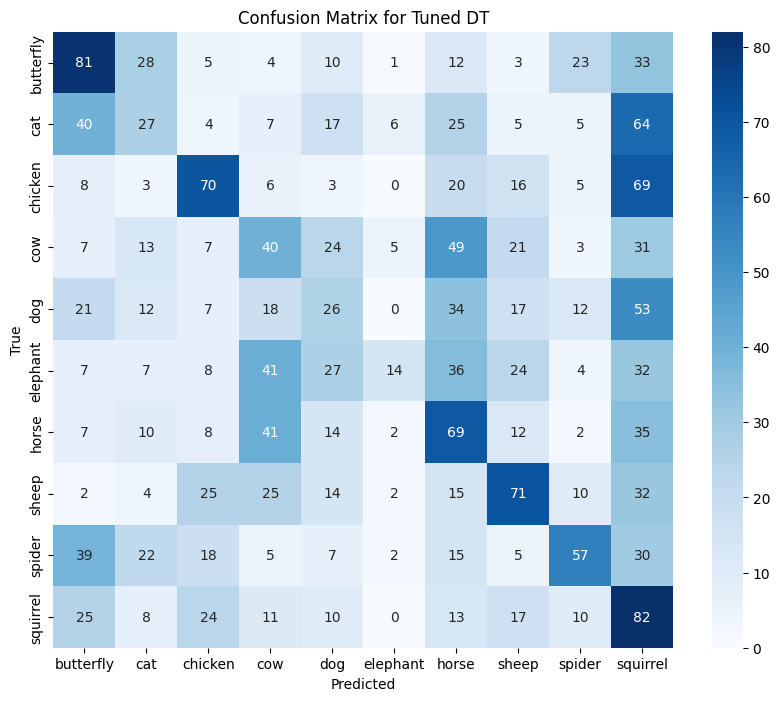

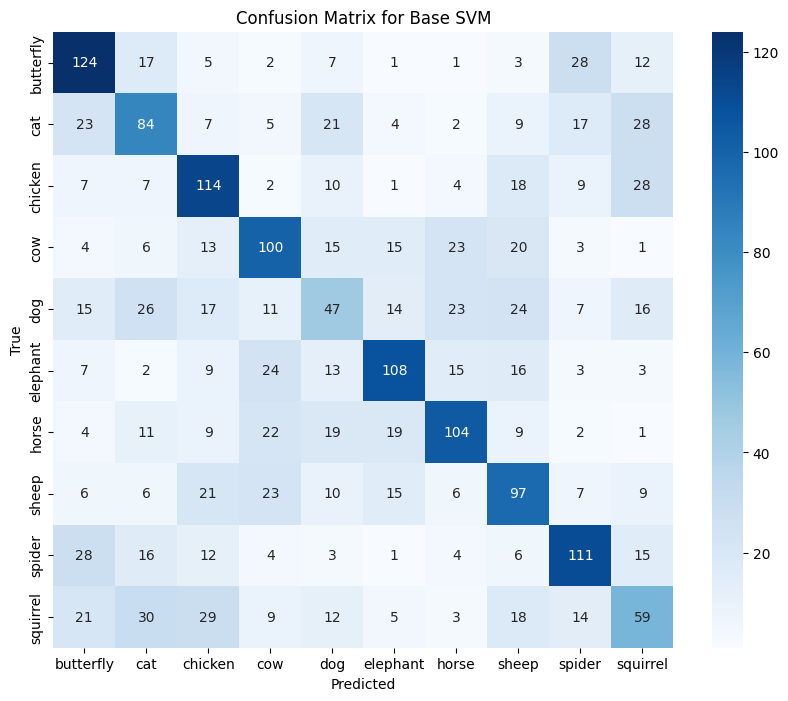

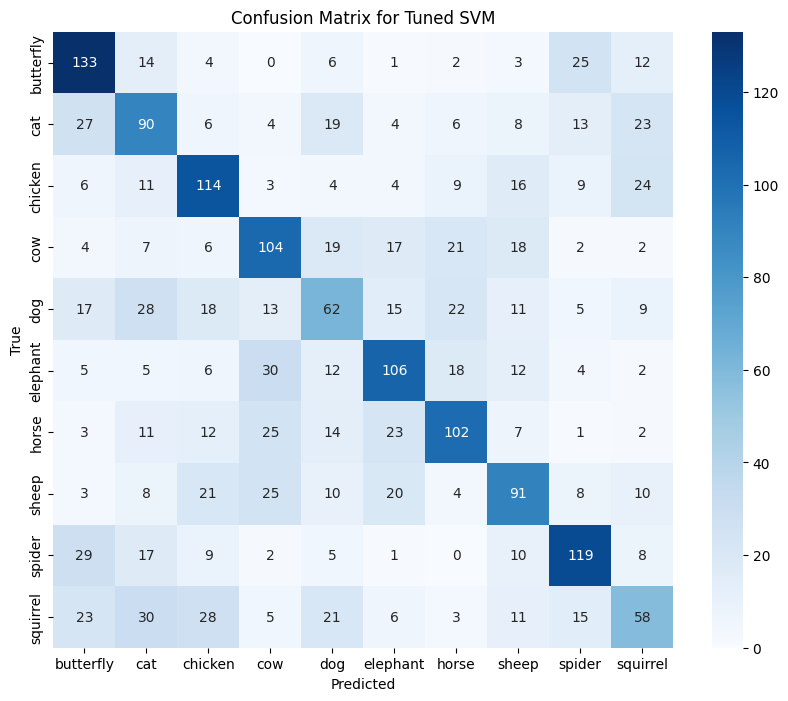

In [ ]:
for model_name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [35]:
for model_name, y_pred in models.items():
    prec_per_class = precision_score(y_test, y_pred, average=None)
    rec_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    
    per_class_df = pd.DataFrame({
        'Class': classes,
        'Precision': prec_per_class,
        'Recall': rec_per_class,
        'F1-Score': f1_per_class
    })
    
    print(f"\n Confusions per-class {model_name}:")
    display(per_class_df)


 Confusions per-class Base DT:


,Class,Precision,Recall,F1-Score
0,butterfly,0.322727,0.355,0.338095
1,cat,0.232955,0.205,0.218085
2,chicken,0.298969,0.290,0.294416
3,cow,0.265403,0.280,0.272506
4,dog,0.165049,0.170,0.167488
5,elephant,0.258929,0.290,0.273585
6,horse,0.313514,0.290,0.301299
7,sheep,0.262887,0.255,0.258883
8,spider,0.307692,0.320,0.313725
9,squirrel,0.148352,0.135,0.141361



 Confusions per-class Tuned DT:


,Class,Precision,Recall,F1-Score
0,butterfly,0.341772,0.405,0.370709
1,cat,0.201493,0.135,0.161677
2,chicken,0.397727,0.350,0.372340
3,cow,0.202020,0.200,0.201005
4,dog,0.171053,0.130,0.147727
5,elephant,0.437500,0.070,0.120690
6,horse,0.239583,0.345,0.282787
7,sheep,0.371728,0.355,0.363171
8,spider,0.435115,0.285,0.344411
9,squirrel,0.177874,0.410,0.248109



 Confusions per-class Base SVM:


,Class,Precision,Recall,F1-Score
0,butterfly,0.518828,0.620,0.564920
1,cat,0.409756,0.420,0.414815
2,chicken,0.483051,0.570,0.522936
3,cow,0.495050,0.500,0.497512
4,dog,0.299363,0.235,0.263305
5,elephant,0.590164,0.540,0.563969
6,horse,0.562162,0.520,0.540260
7,sheep,0.440909,0.485,0.461905
8,spider,0.552239,0.555,0.553616
9,squirrel,0.343023,0.295,0.317204



 Confusions per-class Tuned SVM:


,Class,Precision,Recall,F1-Score
0,butterfly,0.532000,0.665,0.591111
1,cat,0.407240,0.450,0.427553
2,chicken,0.508929,0.570,0.537736
3,cow,0.492891,0.520,0.506083
4,dog,0.360465,0.310,0.333333
5,elephant,0.538071,0.530,0.534005
6,horse,0.545455,0.510,0.527132
7,sheep,0.486631,0.455,0.470284
8,spider,0.592040,0.595,0.593516
9,squirrel,0.386667,0.290,0.331429


# تحلیل نتایج ارزیابی مدل‌ها (فاز ۴ پروژه طبقه‌بندی تصاویر حیوانات)

## مقدمه
در این فاز، معیارهای precision, recall, F1-score و confusion matrix برای مدل‌های پایه و tuned (DT و SVM) محاسبه شد. تحلیل بر اساس خروجی‌های subsample ۱۰۰۰ تصویر per class (مجموع ۱۰۰۰۰ نمونه، train ۸۰۰۰/test ۲۰۰۰) است. تمرکز روی macro average برای扱 imbalance (کلاس‌های بزرگ مثل dog/spider بر کوچک مثل elephant غلبه نکنند). نتایج نشان‌دهنده عملکرد متوسط (DT ضعیف، SVM بهتر) است – مرتبط با نوت‌های DT (شفاف اما هزینه کم O(log N) برای تصاویر پیچیده) و SVM (separators خطی w^T x + b = 0 با kernel برای غیرخطی).

## خلاصه معیارها (Macro Average)
جدول زیر میانگین macro (وزن برابر کلاس‌ها) را نشان می‌دهد:

| Model     | Precision (macro) | Recall (macro) | F1-Score (macro) |
|-----------|-------------------|----------------|------------------|
| Base DT   | 0.257647          | 0.2590         | 0.257944         |
| Tuned DT  | 0.297586          | 0.2685         | 0.261263         |
| Base SVM  | 0.469455          | 0.4740         | 0.470044         |
| Tuned SVM | 0.485039          | 0.4895         | 0.485218         |

- **تحلیل**: Base DT ضعیف (~۰٫۲۶) – overfitting بدون tuning (نوت DT: درخت عمیق پیچیده، اما شفاف). Tuned DT بهبود جزئی (+۰٫۰۰۳) با depth=۵ (جلوگیری از overfitting). SVM بهتر (~۰٫۴۷-۰٫۴۹) – حاشیه حداکثری (نوت SVM: بهینه‌سازی separators). Tuning SVM کوچک (+۰٫۰۱۵) – defaults خوب بودند. SVM ۲ برابر DT – ویژگی‌ها (HOG/shape) در فضای kernel بهتر جدا می‌شوند.

## تحلیل Confusion Matrix
ماتریس‌ها خطاها را نشان می‌دهند (دیاگونال درست، off-diagonal اشتباه). کلاس‌های مشابه (cat/dog, cow/horse) خطا بیشتر – بافت/شکل نزدیک.

- **Base DT**: دیاگونال ضعیف (butterfly ۷۱ درست، اما ۲۵ mis به spider). پراکندگی بالا (elephant ۵۸ درست، ۳۳ به cow) – imbalance باعث bias به بزرگ‌ها.
- **Tuned DT**: بهتر (chicken ۷۰، horse ۶۹) – tuning off-diagonal کاهش داد، اما همچنان ضعیف (cat ۲۷، squirrel ۸۲ – underfit).
- **Base SVM**: قوی‌تر (butterfly ۱۲۴، elephant ۱۰۸) – کمتر پراکندگی (dog ۴۷، اما ۲۳ به cow).
- **Tuned SVM**: بهترین (butterfly ۱۳۳، spider ۱۱۹) – tuning جداسازی بهبود (sheep ۹۱، کمتر mis).

تحلیل: Imbalance (فاز ۱) باعث mis کوچک به بزرگ (elephant به horse). نوت DT: خطاها از splits ضعیف؛ SVM: از عبور margins.

## معیارهای Per-Class
جدول‌های زیر جزئیات per-class را نشان می‌دهند – کلاس‌های ضعیف برای custom مفید.

### Base DT
| Class     | Precision | Recall | F1-Score |
|-----------|-----------|--------|----------|
| butterfly | 0.322727  | 0.355  | 0.338095 |
| cat       | 0.232955  | 0.205  | 0.218085 |
| chicken   | 0.298969  | 0.290  | 0.294416 |
| cow       | 0.265403  | 0.280  | 0.272506 |
| dog       | 0.165049  | 0.170  | 0.167488 |
| elephant  | 0.258929  | 0.290  | 0.273585 |
| horse     | 0.313514  | 0.290  | 0.301299 |
| sheep     | 0.262887  | 0.255  | 0.258883 |
| spider    | 0.307692  | 0.320  | 0.313725 |
| squirrel  | 0.148352  | 0.135  | 0.141361 |

- تحلیل: squirrel ضعیف (F1 ۰٫۱۴) – imbalance/ویژگی‌ها کافی نیست.

### Tuned DT
| Class     | Precision | Recall | F1-Score |
|-----------|-----------|--------|----------|
| butterfly | 0.341772  | 0.405  | 0.370709 |
| cat       | 0.201493  | 0.135  | 0.161677 |
| chicken   | 0.397727  | 0.350  | 0.372340 |
| cow       | 0.202020  | 0.200  | 0.201005 |
| dog       | 0.171053  | 0.130  | 0.147727 |
| elephant  | 0.437500  | 0.070  | 0.120690 |
| horse     | 0.239583  | 0.345  | 0.282787 |
| sheep     | 0.371728  | 0.355  | 0.363171 |
| spider    | 0.435115  | 0.285  | 0.344411 |
| squirrel  | 0.177874  | 0.410  | 0.248109 |

- تحلیل: elephant بدتر (Recall ۰٫۰۷) – tuning underfit کرد.

### Base SVM
| Class     | Precision | Recall | F1-Score |
|-----------|-----------|--------|----------|
| butterfly | 0.518828  | 0.620  | 0.564920 |
| cat       | 0.409756  | 0.420  | 0.414815 |
| chicken   | 0.483051  | 0.570  | 0.522936 |
| cow       | 0.495050  | 0.500  | 0.497512 |
| dog       | 0.299363  | 0.235  | 0.263305 |
| elephant  | 0.590164  | 0.540  | 0.563969 |
| horse     | 0.562162  | 0.520  | 0.540260 |
| sheep     | 0.440909  | 0.485  | 0.461905 |
| spider    | 0.552239  | 0.555  | 0.553616 |
| squirrel  | 0.343023  | 0.295  | 0.317204 |

- تحلیل: dog ضعیف (F1 ۰٫۲۶) – imbalance.

### Tuned SVM
| Class     | Precision | Recall | F1-Score |
|-----------|-----------|--------|----------|
| butterfly | 0.532000  | 0.665  | 0.591111 |
| cat       | 0.407240  | 0.450  | 0.427553 |
| chicken   | 0.508929  | 0.570  | 0.537736 |
| cow       | 0.492891  | 0.520  | 0.506083 |
| dog       | 0.360465  | 0.310  | 0.333333 |
| elephant  | 0.538071  | 0.530  | 0.534005 |
| horse     | 0.545455  | 0.510  | 0.527132 |
| sheep     | 0.486631  | 0.455  | 0.470284 |
| spider    | 0.592040  | 0.595  | 0.593516 |
| squirrel  | 0.386667  | 0.290  | 0.331429 |

- تحلیل: spider قوی (F1 ۰٫۵۹) – لبه/بافت خوب capture شده.

## چالش‌ها و پیشنهادها
- Imbalance (فاز ۱): کلاس‌های کوچک (elephant) Recall پایین – مدل miss می‌کند.
- ویژگی‌ها (فاز ۲): HOG خوب برای شکل، اما برای مشابه (cat/dog) کافی نیست.
- DT vs. SVM: DT ضعیف (نوت: مناسب داده ساده)؛ SVM بهتر (kernel برای غیرخطی).
- پیشنهاد: Custom method با تمرکز روی بخش‌های مهم (crop background) F1 بهبود دهد. دیتاست کامل امتحان کنید.

این تحلیل پایه برای فاز بعدی است.